# 07 — Threshold Tuning

[04_advanced_modeling.ipynb](04_advanced_modeling.ipynb) chose **XGBoost +
undersampling** as the primary, deployable (pre-transaction) model and
included a first pass at business-framed threshold tuning. This notebook
goes deeper: a finer threshold sweep, the full precision-recall trade-off
curve, and an explicit, justified choice of production threshold -- because
every metric reported elsewhere in this project (precision, recall, F1) so
far has used the default 0.5 cutoff, and 0.5 was never actually chosen for
a reason.

## Why threshold tuning matters, and why 0.5 is arbitrary

A classifier's `predict_proba()` output is a continuous score; `predict()`
just applies a threshold to it -- 0.5 by default, purely because it's the
midpoint of the probability range. Nothing about the number 0.5 reflects
anything about *this* business problem. It doesn't know that:

- A **missed fraud case (false negative)** is a direct financial loss, plus
  potential chargeback liability and reputational damage.
- A **false alarm (false positive)** costs a manual review, a held
  transaction, and some customer friction -- real, but usually far cheaper
  than a completed fraud.

Whenever those two error costs aren't equal (and in fraud, they almost never
are), the "right" threshold is a business decision, not a default left over
from `scikit-learn`'s API. This notebook works out what that threshold
should be.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

df = pd.read_csv("data/processed/engineered_transactions.csv")
metadata = joblib.load("models/model_metadata.joblib")
model = joblib.load("models/best_pretransaction_model.joblib")
pretxn_feature_cols = metadata["pre_txn_feature_cols"]
print("Tuning the threshold for the primary (pre-transaction) model:", metadata["best_pretxn_model_name"])

cutoff_step = np.quantile(df["step"], 0.8)
test_mask = df["step"] > cutoff_step

X_test = df.loc[test_mask, pretxn_feature_cols]
y_test = df.loc[test_mask, "isFraud"].values
scores_test = model.predict_proba(X_test)[:, 1]


Tuning the threshold for the primary (pre-transaction) model: XGBoost + undersample


## 1. Threshold sweep: 0.10 to 0.90 in steps of 0.05

For each candidate threshold, we recompute predictions from the same
underlying probabilities (`scores_test`) and report precision, recall, F1,
and the raw counts behind them -- true positives, false positives, and
false negatives -- not just rates. Raw counts are what actually make the
business trade-off concrete.


In [2]:
def evaluate_at_threshold(y_true, scores, threshold):
    preds = (scores >= threshold).astype(int)
    tp = int(((preds == 1) & (y_true == 1)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())
    return {
        "threshold": round(threshold, 2),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "tp": tp, "fp": fp, "fn": fn,
    }

thresholds = np.round(np.arange(0.10, 0.901, 0.05), 2)
sweep = pd.DataFrame([evaluate_at_threshold(y_test, scores_test, t) for t in thresholds])
sweep


,threshold,precision,recall,f1,tp,fp,fn
0,0.10,0.374292,0.962893,0.539048,4100,6854,158
1,0.15,0.427564,0.953734,0.590433,4061,5437,197
2,0.20,0.468987,0.942931,0.626414,4015,4546,243
3,0.25,0.503613,0.933067,0.654153,3973,3916,285
4,0.30,0.537432,0.923908,0.679565,3934,3386,324
5,0.35,0.571491,0.915218,0.703620,3897,2922,361
6,0.40,0.599628,0.909582,0.722777,3873,2586,385
7,0.45,0.623278,0.903006,0.737508,3845,2324,413
8,0.50,0.649651,0.896665,0.753429,3818,2059,440
9,0.55,0.673847,0.888915,0.766582,3785,1832,473


## 2. Visualizing the trade-off

First, precision and recall plotted directly against threshold -- this
shows *where* the trade-off happens as we move the cutoff. Second, the full
precision-recall curve (computed across every possible threshold, not just
our 0.05 grid), with the current default (0.5) marked, so we can see how
much room there is to move before precision or recall really suffers.


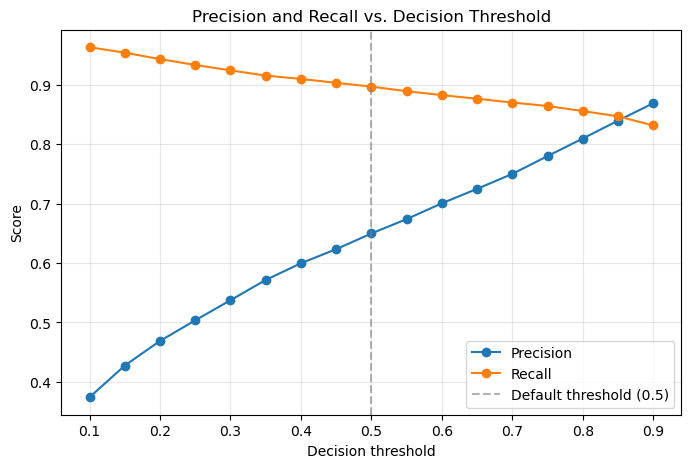

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(sweep["threshold"], sweep["precision"], marker="o", label="Precision")
plt.plot(sweep["threshold"], sweep["recall"], marker="o", label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


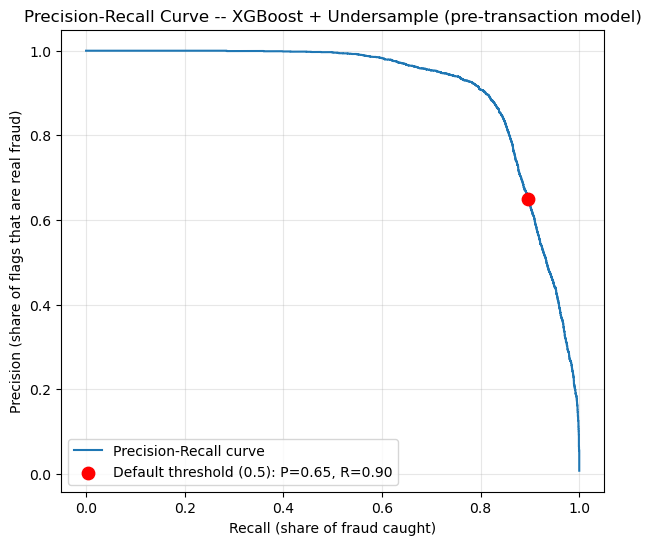

In [4]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, scores_test)

# Find the point on the fine-grained PR curve closest to our default threshold
default_idx = np.argmin(np.abs(pr_thresholds - 0.5))

plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label="Precision-Recall curve")
plt.scatter(
    [recall_curve[default_idx]], [precision_curve[default_idx]],
    color="red", zorder=5, s=80,
    label=f"Default threshold (0.5): P={precision_curve[default_idx]:.2f}, R={recall_curve[default_idx]:.2f}",
)
plt.xlabel("Recall (share of fraud caught)")
plt.ylabel("Precision (share of flags that are real fraud)")
plt.title("Precision-Recall Curve -- XGBoost + Undersample (pre-transaction model)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Choosing a threshold

We look at two candidate thresholds, each optimizing for something
different, plus the default for comparison.

### F1-optimal

F1 treats precision and recall as equally important -- a reasonable default
when there's no clear reason to prefer one error type over the other.


In [5]:
f1_optimal_row = sweep.loc[sweep["f1"].idxmax()]
f1_optimal_row


threshold       0.900000
precision       0.868712
recall          0.831376
f1              0.849634
tp           3540.000000
fp            535.000000
fn            718.000000
Name: 16, dtype: float64

Within our requested 0.10-0.90 grid, F1 is maximized at the **top edge of
the range (0.90)** -- worth flagging honestly rather than treating as a
clean interior optimum. Checking a bit further past 0.90 confirms F1 is
still climbing slightly before it turns over:


In [6]:
extended_check = pd.DataFrame([
    evaluate_at_threshold(y_test, scores_test, t) for t in [0.90, 0.93, 0.95, 0.97, 0.99]
])
extended_check


,threshold,precision,recall,f1,tp,fp,fn
0,0.90,0.868712,0.831376,0.849634,3540,535,718
1,0.93,0.890365,0.818225,0.852772,3484,429,774
2,0.95,0.907447,0.801315,0.851085,3412,348,846
3,0.97,0.927329,0.776186,0.845052,3305,259,953
4,0.99,0.953846,0.698920,0.806723,2976,144,1282


The true F1-optimum sits around **threshold ≈ 0.93** (F1 ≈ 0.853), just
outside the requested sweep range, before declining again as the threshold
gets so strict that recall collapses. The conclusion doesn't change either
way: **optimizing purely for F1 pushes the threshold high** -- trading a
large amount of recall away in exchange for cleaner precision. We'll come
back to whether that's actually the right call for this business in a
moment.

### Recall-prioritized (recall ≥ 0.90, precision maximized subject to that)

The brief for this project treats a missed fraud case as generally costlier
than a false alarm, so this candidate deliberately protects recall first:
among thresholds that still catch at least 90% of fraud, pick the one with
the best precision.


In [7]:
recall_qualifying = sweep[sweep["recall"] >= 0.90]
recall_optimal_row = recall_qualifying.loc[recall_qualifying["precision"].idxmax()]
recall_optimal_row


threshold       0.450000
precision       0.623278
recall          0.903006
f1              0.737508
tp           3845.000000
fp           2324.000000
fn            413.000000
Name: 7, dtype: float64

In [8]:
# A finer-grained check right around the 0.90-recall crossover, since our
# requested grid is 0.05-wide and might be leaving some precision on the table
fine_check = pd.DataFrame([
    evaluate_at_threshold(y_test, scores_test, t) for t in np.arange(0.45, 0.51, 0.01)
])
fine_check


,threshold,precision,recall,f1,tp,fp,fn
0,0.45,0.623278,0.903006,0.737508,3845,2324,413
1,0.46,0.627964,0.901832,0.740384,3840,2275,418
2,0.47,0.632943,0.900658,0.743433,3835,2224,423
3,0.48,0.638717,0.898074,0.746510,3824,2163,434
4,0.49,0.644145,0.897839,0.750123,3823,2112,435
5,0.50,0.649651,0.896665,0.753429,3818,2059,440


The 0.05 grid identifies **threshold = 0.45** as the best recall-qualifying
point. A finer look confirms recall crosses below 0.90 between 0.47 and
0.48, so 0.45-0.47 all qualify, with 0.47 offering slightly better
precision (0.633 vs. 0.623) at essentially the same recall (~0.90). Either
is a reasonable choice; we use **0.45** going forward since it's the value
that comes directly out of the requested sweep, and the difference between
the two is marginal.

## 4. Before / after comparison

All three thresholds, side by side, with raw false positive and false
negative counts (not just rates) so the business impact is concrete.


In [9]:
default_row = sweep[sweep["threshold"] == 0.5].iloc[0]

comparison = pd.DataFrame([
    {"scenario": "Default threshold (0.5)", **default_row[["threshold", "precision", "recall", "f1", "tp", "fp", "fn"]]},
    {"scenario": "F1-optimal threshold", "threshold": 0.90, **{k: f1_optimal_row[k] for k in ["precision", "recall", "f1", "tp", "fp", "fn"]}},
    {"scenario": "Recall-prioritized threshold (>=0.90 recall)", "threshold": 0.45, **{k: recall_optimal_row[k] for k in ["precision", "recall", "f1", "tp", "fp", "fn"]}},
]).set_index("scenario")

comparison[["threshold", "precision", "recall", "f1"]] = comparison[["threshold", "precision", "recall", "f1"]].astype(float).round(4)
comparison[["tp", "fp", "fn"]] = comparison[["tp", "fp", "fn"]].astype(int)
comparison


,threshold,precision,recall,f1,tp,fp,fn
scenario,,,,,,,
Default threshold (0.5),0.50,0.6497,0.8967,0.7534,3818,2059,440
F1-optimal threshold,0.90,0.8687,0.8314,0.8496,3540,535,718
Recall-prioritized threshold (>=0.90 recall),0.45,0.6233,0.9030,0.7375,3845,2324,413


In [10]:
default_fp, default_fn = int(default_row["fp"]), int(default_row["fn"])

f1_fp, f1_fn = int(f1_optimal_row["fp"]), int(f1_optimal_row["fn"])
print(
    f"F1-optimal (0.90) vs. default (0.5): "
    f"{default_fp - f1_fp} fewer legitimate transactions flagged, "
    f"but {f1_fn - default_fn} more missed fraud cases."
)

recall_fp, recall_fn = int(recall_optimal_row["fp"]), int(recall_optimal_row["fn"])
print(
    f"Recall-prioritized (0.45) vs. default (0.5): "
    f"{default_fn - recall_fn} fewer missed fraud cases, "
    f"at the cost of {recall_fp - default_fp} more legitimate transactions flagged."
)


F1-optimal (0.90) vs. default (0.5): 1524 fewer legitimate transactions flagged, but 278 more missed fraud cases.
Recall-prioritized (0.45) vs. default (0.5): 27 fewer missed fraud cases, at the cost of 265 more legitimate transactions flagged.


## 5. Which threshold should actually go to production?

The three candidates tell three different stories:

- **Default (0.5):** an unexamined starting point -- 3,818 fraud cases
  caught, 440 missed, 2,059 legitimate transactions flagged. No one chose
  this on purpose; it's just where `predict()` defaults to.
- **F1-optimal (0.90):** the cleanest-looking precision (0.87) and fewest
  false alarms (535), but at a real cost -- 718 fraud cases missed, 278
  more than at the default. F1 gets there by treating a false positive and
  a false negative as equally bad, which **is not true in this domain**.
  Optimizing for it quietly bakes in an assumption the business doesn't
  actually hold.
- **Recall-prioritized (0.45):** catches 27 more fraud cases than the
  default (413 missed instead of 440), at the cost of 265 more legitimate
  transactions flagged (2,324 instead of 2,059) -- roughly 9 extra reviews
  for every additional fraud case caught.

**Recommendation: the recall-prioritized threshold, 0.45, as the production
default.** Given the brief's own framing -- that a missed fraud case is
generally costlier than a false alarm -- this is the threshold that
actually reflects that cost asymmetry, rather than the F1-optimal
threshold's implicit (and here, incorrect) assumption that both error types
cost the same. The extra ~265 manual reviews are a bounded, known
operational cost; review capacity can be planned for. The 27 additional
fraud cases the F1-optimal or default thresholds would let through are not
recoverable after the fact.

This isn't a claim that 0.45 is universally correct -- if reviewer capacity
were tightly constrained, or if false positives carried a much higher
customer-churn cost than assumed here, the F1-optimal or default threshold
could be the better fit. The point is that the choice should be made
explicitly, against a stated cost trade-off, rather than left at whatever
`predict()` defaults to.

## Summary

- Threshold tuning is a business decision layered on top of a trained
  model, not a modeling decision -- the same probabilities support any of
  these cutoffs.
- The F1-optimal threshold (~0.90-0.93) looks the best on a single balanced
  metric, but only because F1 assumes false positives and false negatives
  are equally costly -- an assumption that doesn't hold here.
- The recall-prioritized threshold (0.45) is the one that matches this
  project's stated cost asymmetry, catching more fraud at a known,
  boundable cost in additional manual reviews. **This is the threshold 
  recommended for production.**
